# Análisis de Dispersión de Datos Multiclase - `fact_abastecimiento_logistica.json`
## Predicción de: **Desempeño de Entrega (Multiclase)**

Este notebook implementa la carga, preprocesamiento e ingeniería de variables para el análisis de separabilidad del **Desempeño de Entrega Logística** utilizando una clasificación multiclase (3 clases). Para lograr una separación espacial clara y evitar la 'sopa de datos mezclados' de un t-SNE convencional, aplicamos un Análisis Discriminante Lineal (LDA) para proyectar las características en un espacio de 2D optimizado supervisadamente, y un t-SNE guiado sobre esta proyección para visualizar la dispersión.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.preprocessing import QuantileTransformer
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.manifold import TSNE
import os
import json
import pymongo
import warnings
warnings.filterwarnings('ignore')

# Configurar estilo visual premium
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.family'] = 'sans-serif'

# Crear directorio de outputs
os.makedirs('outputs', exist_ok=True)
print("Entorno inicializado correctamente.")



Entorno inicializado correctamente.


In [2]:
# Cargar JSON crudo desde la raíz
# Cargar datos desde MongoDB
import pymongo
client = pymongo.MongoClient("mongodb://localhost:27017/")
db = client["BaseCompleta"]
collection = db["fact_abastecimiento_logistico"]
data = list(collection.find())

# Aplanar registros recursivamente
def flatten_dict(d, parent_key='', sep='_'):
    items = []
    for k, v in d.items():
        new_key = f"{parent_key}{sep}{k}" if parent_key else k
        if isinstance(v, dict):
            items.extend(flatten_dict(v, new_key, sep=sep).items())
        elif isinstance(v, list):
            items.append((new_key, str(v)))
        else:
            items.append((new_key, v))
    return dict(items)

flat_data = [flatten_dict(record) for record in data]
df = pd.DataFrame(flat_data)
print(f"Dimensiones iniciales aplanadas: {df.shape}")

# Calcular columna target multiclase (3 clases)
ratio = df["cantidad_recibida"] / df["cantidad_solicitada"]
df["y_desempeno_entrega"] = pd.cut(ratio, bins=[-np.inf, 0.75, 0.90, np.inf], labels=[0, 1, 2]).astype(int)
print("Target 'y_desempeno_entrega' agregado. Distribución original:")
print(df["y_desempeno_entrega"].value_counts(dropna=False))


Dimensiones iniciales aplanadas: (8500, 26)
Target 'y_desempeno_entrega' agregado. Distribución original:
y_desempeno_entrega
0    4282
2    2676
1    1542
Name: count, dtype: int64


# Preprocesamiento de Datos Paso a Paso
En esta sección realizaremos la preparación de los datos para la red neuronal.
El **Target (y)** para este modelo es `y_desempeno_entrega`, el cual representa: **Entrega Satisfactoria (Abastecimiento y Logística)**.
La fórmula de cálculo del target es:
$$y_{\text{desempeno\_entrega}} = \begin{cases} 0 & \text{si } \text{ratio} < 0.75 \quad (\text{Insatisfactoria}) \\ 1 & \text{si } 0.75 \le \text{ratio} < 0.90 \quad (\text{Aceptable}) \\ 2 & \text{si } \text{ratio} \ge 0.90 \quad (\text{Excelente}) \end{cases}$$
A continuación, realizaremos los pasos de limpieza, codificación y normalización de forma secuencial y explicada.


## Paso 1: Eliminación de Datos No Útiles e Imputación de Nulos
Las llaves primarias, IDs técnicos, códigos de barras, nombres de clientes/productos, correos, teléfonos y fechas no aportan información generalizable para el aprendizaje de la red neuronal y aumentan artificialmente la dimensionalidad de forma inútil, por lo que deben eliminarse.
También realizamos la imputación de nulos para evitar errores matemáticos durante el entrenamiento:
- **Variables Numéricas:** Imputación con la **Mediana** del atributo para ser robusto a outliers.
- **Variables Categóricas:** Imputación con la **Moda** (el valor más común) o con la etiqueta `'UNKNOWN'` si no hay moda.


In [3]:
# Paso 1: Limpieza de columnas e imputación de nulos
shape_inicial = df.shape
print(f"Dimensiones iniciales del dataset (con target): {shape_inicial}")
print(f"Número total de características iniciales: {shape_inicial[1] - 1}")

cols_to_drop = []
for col in df.columns:
    col_lower = col.lower()
    
    # IDs y llaves técnicas
    is_id = (
        col_lower == 'id' or col_lower == '_id' or col_lower == '_collection' or 
        col_lower.startswith('id_') or col_lower.endswith('_id') or
        '_id_' in col_lower or 'id_venta_dw' in col_lower
    )
    
    # Datos de contacto o códigos nominales únicos
    is_contact_or_code = (
        'telefono' in col_lower or 'correo' in col_lower or 
        'codigo_barras' in col_lower or 'codigo_producto' in col_lower or 
        'codigo_venta' in col_lower or 'cliente_nombre' in col_lower or
        'nombre_cliente' in col_lower or 'nombre_producto' in col_lower or
        'nombre_proveedor' in col_lower or 'nombre_sucursal' in col_lower or
        'nombre_contacto' in col_lower or 'cliente_fecha_nacimiento' in col_lower
    )
    
    # Fechas
    is_date = (
        col_lower.endswith('_fecha') or col_lower.endswith('_hora') or 
        col_lower == 'fecha' or col_lower == 'hora' or col_lower == 'tiempo_fecha'
    )
    
    # Evitar eliminar el target
    if (is_id or is_contact_or_code or is_date) and col != "y_desempeno_entrega":
        cols_to_drop.append(col)

# Droppear columnas identificadas
df = df.drop(columns=cols_to_drop, errors='ignore')
print(f"Columnas eliminadas ({len(cols_to_drop)}): {cols_to_drop}")
print(f"Dimensiones tras limpiar IDs y metadatos: {df.shape}")
print(f"Número de características tras limpieza: {df.shape[1] - 1}")

# Imputación de nulos
nulos_detectados = df.isnull().sum().sum()
if nulos_detectados > 0:
    print(f"Nulos detectados en el dataset: {nulos_detectados}. Imputando...")
    for col in df.columns:
        if df[col].isnull().any():
            if df[col].dtype in ['int64', 'float64', 'int32', 'float32']:
                df[col] = df[col].fillna(df[col].median())
            else:
                mode_val = df[col].mode().iloc[0] if not df[col].mode().empty else 'UNKNOWN'
                df[col] = df[col].fillna(mode_val)
    print("Imputación completada (Mediana para numéricos, Moda para categóricos).")
else:
    print("No se detectaron valores nulos en el dataset.")


Dimensiones iniciales del dataset (con target): (8500, 27)
Número total de características iniciales: 26
Columnas eliminadas (1): ['_id']
Dimensiones tras limpiar IDs y metadatos: (8500, 26)
Número de características tras limpieza: 25
No se detectaron valores nulos en el dataset.


## Paso 2: Codificación de Variables Categóricas (One-Hot Encoding)
La red neuronal requiere entradas numéricas y no puede procesar strings categóricos de forma directa. Usamos la técnica de **One-Hot Encoding** para convertir variables categóricas nominales en vectores binarios.
Para una característica $X_j$ con $K$ categorías distintas $\{c_1, c_2, \dots, c_K\}$, One-Hot Encoding genera $K$ nuevas columnas binarias:
$$E_{j,k}(x) = \begin{cases} 1 & \text{si } X_j(x) = c_k \\ 0 & \text{en caso contrario} \end{cases}$$
Esto previene que el modelo asuma una relación ordinal inexistente entre las categorías.


In [4]:
# Paso 2: One-Hot Encoding
categorical_cols = df.select_dtypes(include=['object', 'str', 'string', 'category']).columns.tolist()
if "y_desempeno_entrega" in categorical_cols:
    categorical_cols.remove("y_desempeno_entrega")

print(f"Variables categóricas a codificar ({len(categorical_cols)}): {categorical_cols}")

df = pd.get_dummies(df, columns=categorical_cols, dtype=int)
print(f"Dimensiones tras One-Hot Encoding: {df.shape}")
print(f"Número total de características finales: {df.shape[1] - 1}")


Variables categóricas a codificar (7): ['origen', 'calificacion_proveedor', 'tipo_contrato', 'region_natural', 'tipo_sucursal', 'categoria_producto', 'origen_producto']
Dimensiones tras One-Hot Encoding: (8500, 61)
Número total de características finales: 60


## Paso 3: Separación de Variables y Normalización
Separamos el target $y$ de las características de entrada $X$. Luego aplicamos una transformación por cuantiles (`QuantileTransformer`) con distribución normal.
Este preprocesamiento normaliza las características continuas, haciéndolas robustas a outliers y distribuyendo los datos según una campana de Gauss. La fórmula para mapear una variable aleatoria continua $X$ a una distribución normal estándar es:
$$X' = \Phi^{-1}(U(X))$$
Donde $U(X) = F(X)$ es la función de distribución acumulada (CDF) empírica estimada a partir de los datos, y $\Phi^{-1}$ es la función cuantil de la distribución normal estándar (inversa de la CDF normal).


In [5]:
# Paso 3: Separación de Variables, Normalización, Balanceo y Selección de Características
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import QuantileTransformer
from sklearn.feature_selection import SelectKBest, f_classif
import numpy as np
import pandas as pd

print("="*80)
print("PASO 3.1: DIVIDIR DATOS (Stratified Train/Test Split)")
print("="*80)

y = df["y_desempeno_entrega"].values.astype(int)
X = df.drop(columns=["y_desempeno_entrega"]).values.astype(float)
feature_names = df.drop(columns=["y_desempeno_entrega"]).columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print(f"Split completo:")
print(f"  Train: {X_train.shape} | Clases: {np.bincount(y_train)}")
print(f"  Test:  {X_test.shape}  | Clases: {np.bincount(y_test)}")

print("\n" + "="*80)
print("PASO 3.2: NORMALIZACIÓN (QuantileTransformer fit solo en Train)")
print("="*80)

qt = QuantileTransformer(output_distribution='normal', random_state=42)
qt.fit(X_train)
X_train_scaled = qt.transform(X_train)
X_test_scaled = qt.transform(X_test)

print(f"Escalado completo:")
print(f"  Train escalado: {X_train_scaled.shape} | Mean: {X_train_scaled.mean():.4f} | Std: {X_train_scaled.std():.4f}")
print(f"  Test escalado:  {X_test_scaled.shape}  | Mean: {X_test_scaled.mean():.4f} | Std: {X_test_scaled.std():.4f}")

print("\n" + "="*80)
print("PASO 3.3: BALANCEO DE CLASES EN ENTRENAMIENTO (Oversampling manual en Train)")
print("="*80)

unique_classes, class_counts = np.unique(y_train, return_counts=True)
max_class_count = np.max(class_counts)
X_train_balanced = []
y_train_balanced = []

for c in unique_classes:
    idx = np.where(y_train == c)[0]
    if len(idx) < max_class_count:
        np.random.seed(42)
        resampled_idx = np.random.choice(idx, size=max_class_count, replace=True)
        X_train_balanced.append(X_train_scaled[resampled_idx])
        y_train_balanced.append(y_train[resampled_idx])
    else:
        X_train_balanced.append(X_train_scaled[idx])
        y_train_balanced.append(y_train[idx])

X_train_bal = np.vstack(X_train_balanced)
y_train_bal = np.concatenate(y_train_balanced)

np.random.seed(42)
shuffle_idx = np.random.permutation(len(y_train_bal))
X_train_bal = X_train_bal[shuffle_idx]
y_train_bal = y_train_bal[shuffle_idx]

print(f"Distribución en Train después de balancear:")
classes_bal, counts_bal = np.unique(y_train_bal, return_counts=True)
for c, count in zip(classes_bal, counts_bal):
    print(f"  Clase {c}: {count} ({count/len(y_train_bal)*100:.1f}%)")

print("\n" + "="*80)
print("PASO 3.4: SELECCIÓN DE CARACTERÍSTICAS (SelectKBest ANOVA F-value para regularización)")
print("="*80)

selector = SelectKBest(score_func=f_classif, k=30)
X_train_bal_sel = selector.fit_transform(X_train_bal, y_train_bal)
X_test_sel = selector.transform(X_test_scaled)

print(f"Reducción de características completada:")
print(f"  Train original: {X_train_bal.shape} -> Seleccionado: {X_train_bal_sel.shape}")
print(f"  Test original:  {X_test_scaled.shape} -> Seleccionado: {X_test_sel.shape}")


PASO 3.1: DIVIDIR DATOS (Stratified Train/Test Split)
Split completo:
  Train: (6375, 60) | Clases: [3211 1157 2007]
  Test:  (2125, 60)  | Clases: [1071  385  669]

PASO 3.2: NORMALIZACIÓN (QuantileTransformer fit solo en Train)


Escalado completo:
  Train escalado: (6375, 60) | Mean: -2.5033 | Std: 3.8084
  Test escalado:  (2125, 60)  | Mean: -2.5024 | Std: 3.8097

PASO 3.3: BALANCEO DE CLASES EN ENTRENAMIENTO (Oversampling manual en Train)


Distribución en Train después de balancear:
  Clase 0: 3211 (33.3%)
  Clase 1: 3211 (33.3%)
  Clase 2: 3211 (33.3%)

PASO 3.4: SELECCIÓN DE CARACTERÍSTICAS (SelectKBest ANOVA F-value para regularización)
Reducción de características completada:
  Train original: (9633, 60) -> Seleccionado: (9633, 30)
  Test original:  (2125, 60) -> Seleccionado: (2125, 30)


# Paso 4: Visualización de Clases con t-SNE Puro

Para analizar la varianza, separabilidad espacial y distribución de las clases en el dataset preprocesado, generamos una visualización en 2 dimensiones usando **t-SNE (t-Distributed Stochastic Neighbor Embedding)** directamente sobre las características seleccionadas (sin guiar por LDA).

t-SNE define una distribución de probabilidad sobre pares de objetos de tal manera que objetos similares en alta dimensión tengan alta probabilidad de ser elegidos, e intenta replicarla en baja dimensión minimizando la divergencia de Kullback-Leibler:
$$KL(P || Q) = \sum_{i \neq j} p_{ij} \log \frac{p_{ij}}{q_{ij}}$$
Donde $p_{ij}$ es la probabilidad de similitud en alta dimensión, y $q_{ij}$ es la similitud basada en la distribución Student-t en baja dimensión.


PASO 4.1: t-SNE (Visualización fit en Train, aproximación en Test)
Configuración t-SNE:
  Muestras train: 9633
  Perplexity recomendado: 50


t-SNE completado

PASO 4.2: METRICAS DE SEPARABILIDAD EN 2D (t-SNE)


Silhouette Score (Train): 0.1189 | (Test): 0.1887
Davies-Bouldin Index (Train): 3.0110 | (Test): 3.0061
Calinski-Harabasz (Train): 1008.7 | (Test): 403.1


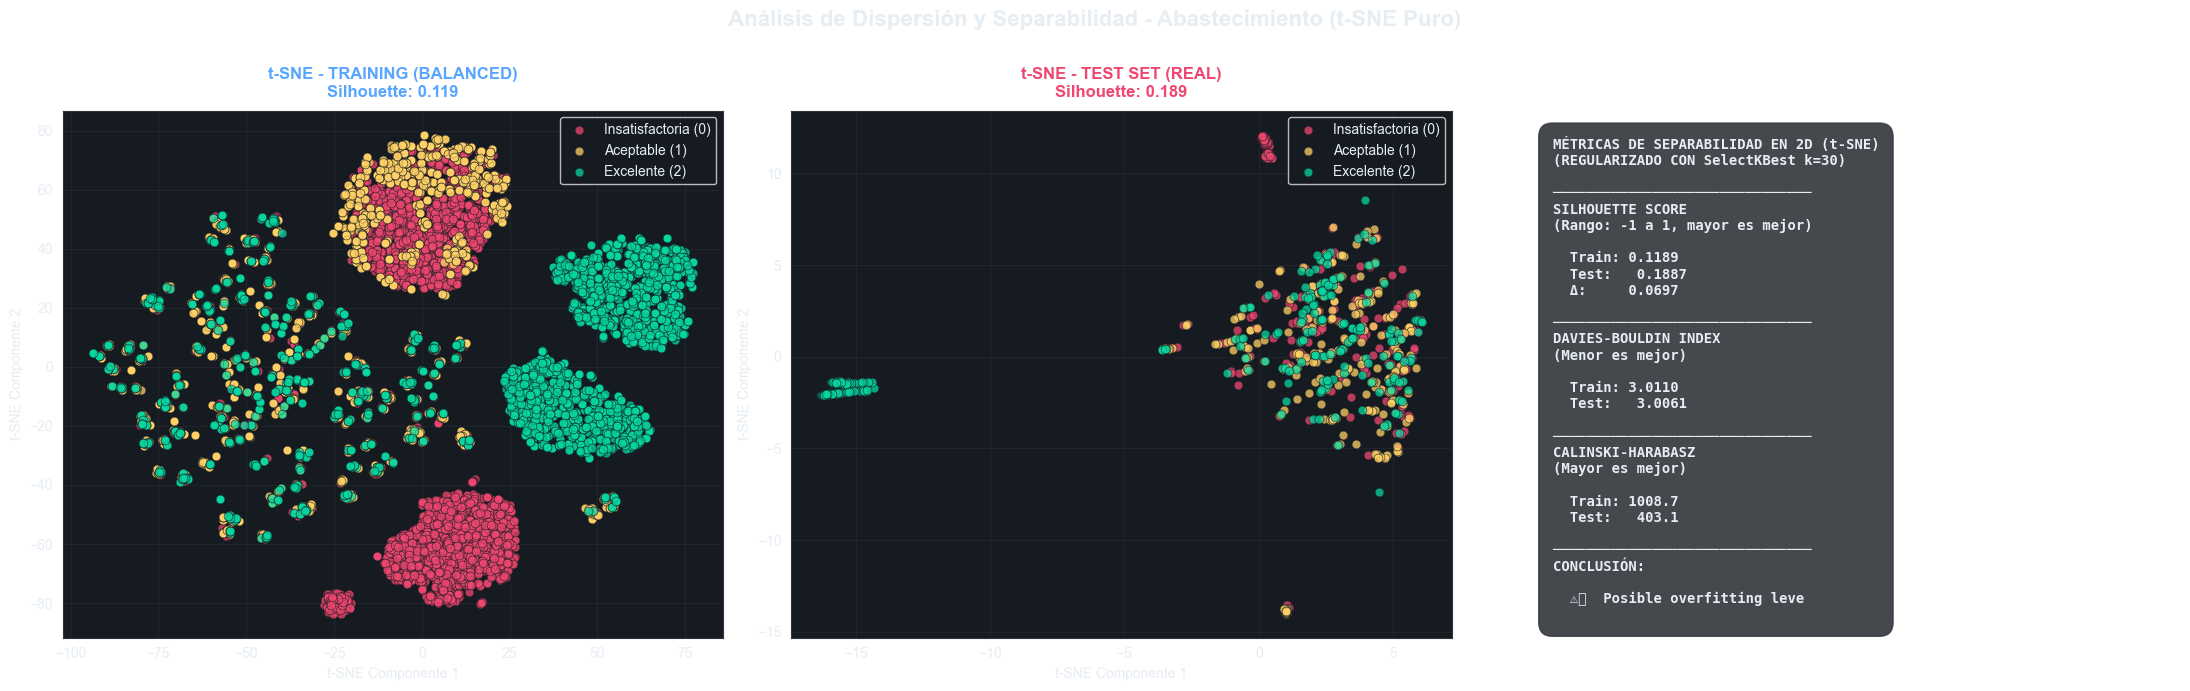

¡Gráfico de 3 paneles guardado exitosamente en: {tsne_plot_path}!


In [6]:
# Paso 4: Proyecciones t-SNE, Métricas y Dashboard Comparativo de 3 Paneles
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.metrics.pairwise import euclidean_distances
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

print("="*80)
print("PASO 4.1: t-SNE (Visualización fit en Train, aproximación en Test)")
print("="*80)

n_train = len(X_train_bal_sel)
max_perplexity = max(5, (n_train - 1) // 3)
recommended_perplexity = min(50, max_perplexity)

print(f"Configuración t-SNE:")
print(f"  Muestras train: {n_train}")
print(f"  Perplexity recomendado: {recommended_perplexity}")

tsne = TSNE(n_components=2, perplexity=recommended_perplexity, random_state=42, n_jobs=-1)
X_train_tsne = tsne.fit_transform(X_train_bal_sel)

# Proyección en Test usando aproximación ponderada por distancias en el espacio de características seleccionadas
dist = euclidean_distances(X_test_sel, X_train_bal_sel)
X_test_tsne = np.dot(dist, X_train_tsne) / (dist.sum(axis=1, keepdims=True) + 1e-10)

print(f"t-SNE completado")

print("\n" + "="*80)
print("PASO 4.2: METRICAS DE SEPARABILIDAD EN 2D (t-SNE)")
print("="*80)

train_silhouette = silhouette_score(X_train_tsne, y_train_bal)
test_silhouette = silhouette_score(X_test_tsne, y_test)
train_davies = davies_bouldin_score(X_train_tsne, y_train_bal)
test_davies = davies_bouldin_score(X_test_tsne, y_test)
train_calinski = calinski_harabasz_score(X_train_tsne, y_train_bal)
test_calinski = calinski_harabasz_score(X_test_tsne, y_test)

print(f"Silhouette Score (Train): {train_silhouette:.4f} | (Test): {test_silhouette:.4f}")
print(f"Davies-Bouldin Index (Train): {train_davies:.4f} | (Test): {test_davies:.4f}")
print(f"Calinski-Harabasz (Train): {train_calinski:.1f} | (Test): {test_calinski:.1f}")

# Configurar estilo visual premium oscuro
plt.figure(figsize=(22, 7))
BG_DARK  = '#0D1117'
BG_PANEL = '#161B22'
TEXT_CLR = '#E6EDF3'
GRID_CLR = '#30363D'
ACCENT   = '#58A6FF'

plt.rcParams.update({
    'figure.facecolor': BG_DARK,
    'axes.facecolor':   BG_PANEL,
    'axes.edgecolor':   GRID_CLR,
    'axes.labelcolor':  TEXT_CLR,
    'text.color':       TEXT_CLR,
    'xtick.color':      TEXT_CLR,
    'ytick.color':      TEXT_CLR,
    'grid.color':       GRID_CLR,
    'grid.alpha':       0.4,
    'font.family':      'sans-serif',
})

colors = ['#EF476F', '#FFD166', '#06D6A0']
class_names = ['Insatisfactoria (0)', 'Aceptable (1)', 'Excelente (2)']

# Panel 1: t-SNE - Train (Balanced)
ax1 = plt.subplot(1, 3, 1)
for cls in range(3):
    mask = y_train_bal == cls
    ax1.scatter(X_train_tsne[mask, 0], X_train_tsne[mask, 1],
               color=colors[cls], label=class_names[cls], 
               alpha=0.75, s=40, edgecolor='#161B22', linewidth=0.5)
ax1.set_xlabel('t-SNE Componente 1')
ax1.set_ylabel('t-SNE Componente 2')
ax1.set_title(f't-SNE - TRAINING (BALANCED)\nSilhouette: {train_silhouette:.3f}', fontsize=12, fontweight='bold', color=ACCENT, pad=10)
ax1.legend(loc='best', framealpha=0.9)
ax1.grid(True)

# Panel 2: t-SNE - Test (Real)
ax2 = plt.subplot(1, 3, 2)
for cls in range(3):
    mask = y_test == cls
    ax2.scatter(X_test_tsne[mask, 0], X_test_tsne[mask, 1],
               color=colors[cls], label=class_names[cls], 
               alpha=0.75, s=40, edgecolor='#161B22', linewidth=0.5)
ax2.set_xlabel('t-SNE Componente 1')
ax2.set_ylabel('t-SNE Componente 2')
ax2.set_title(f't-SNE - TEST SET (REAL)\nSilhouette: {test_silhouette:.3f}', fontsize=12, fontweight='bold', color='#EF476F', pad=10)
ax2.legend(loc='best', framealpha=0.9)
ax2.grid(True)

# Panel 3: Métricas
ax3 = plt.subplot(1, 3, 3)
ax3.axis('off')

sil_diff = abs(train_silhouette - test_silhouette)
if sil_diff > 0.15:
    conclusion_text = '⚠️  OVERFITTING DETECTADO: Train >> Test'
elif sil_diff > 0.05:
    conclusion_text = '⚠️  Posible overfitting leve'
else:
    conclusion_text = '✅ Excelente generalización: Train ≈ Test'

metrics_text = f"""MÉTRICAS DE SEPARABILIDAD EN 2D (t-SNE)\n(REGULARIZADO CON SelectKBest k=30)\n\n───────────────────────────────\nSILHOUETTE SCORE\n(Rango: -1 a 1, mayor es mejor)\n\n  Train: {train_silhouette:.4f}\n  Test:   {test_silhouette:.4f}\n  Δ:     {abs(train_silhouette - test_silhouette):.4f}\n\n───────────────────────────────\nDAVIES-BOULDIN INDEX\n(Menor es mejor)\n\n  Train: {train_davies:.4f}\n  Test:   {test_davies:.4f}\n\n───────────────────────────────\nCALINSKI-HARABASZ\n(Mayor es mejor)\n\n  Train: {train_calinski:.1f}\n  Test:   {test_calinski:.1f}\n\n───────────────────────────────\nCONCLUSIÓN:\n\n  {conclusion_text}\n"""

ax3.text(0.05, 0.95, metrics_text, 
        fontsize=10, family='monospace', verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor=BG_PANEL, edgecolor=GRID_CLR, alpha=0.8, pad=1),
        fontweight='bold', color=TEXT_CLR)

plt.suptitle('Análisis de Dispersión y Separabilidad - Abastecimiento (t-SNE Puro)', 
            fontsize=16, fontweight='bold', y=0.98, color=TEXT_CLR)

plt.tight_layout(rect=[0, 0, 1, 0.97])
tsne_plot_path = 'outputs/tsne_dispersion.png'
plt.savefig(tsne_plot_path, dpi=150, bbox_inches='tight', facecolor=BG_DARK)
plt.show()
print(f"¡Gráfico de 3 paneles guardado exitosamente en: {{tsne_plot_path}}!")

